In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv(
    "../processed_data/final_merged_dataset.csv"
)

In [25]:
df.head()

,review,clean_review,sentiment,rating,domain,review_length
0,Perhaps this could be the best movie ever made...,perhaps could best movie ever made not certain...,Positive,8.0,movie,1021
1,Being a fan of time travel stories I was surpr...,fan time travel story surprised device sent ru...,Positive,8.0,movie,820
2,This movie is awesome due to the fact that it ...,movie awesome due fact showed good cartoon rea...,Positive,8.0,movie,547
3,"RO filter candle,Good product and fit perfectl...",ro filter candle good product fit perfectly th...,Neutral,3.9,ecommerce,482
4,Extremely Tasty!,extremely tasty,Positive,8.0,restaurant,16


In [26]:
df.shape

(7722, 6)

In [27]:
df.columns

Index(['review', 'clean_review', 'sentiment', 'rating', 'domain',
       'review_length'],
      dtype='str')

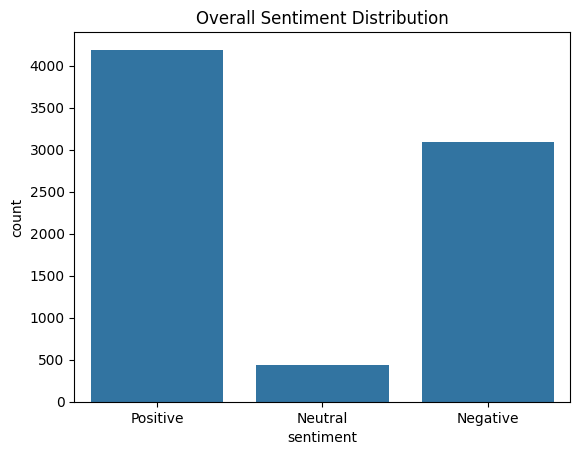

In [28]:
#overall sentiment
sns.countplot(
    x="sentiment",
    data=df
)

plt.title(
    "Overall Sentiment Distribution"
)

plt.show()

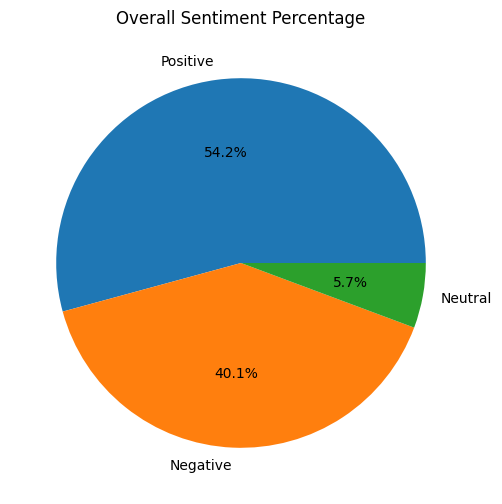

In [29]:
df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title(
    "Overall Sentiment Percentage"
)

plt.ylabel("")

plt.show()

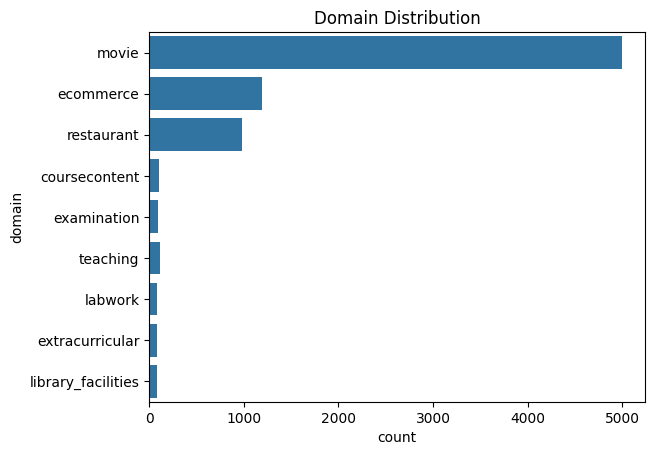

In [30]:
sns.countplot(
    y="domain",
    data=df
)

plt.title(
    "Domain Distribution"
)

plt.show()

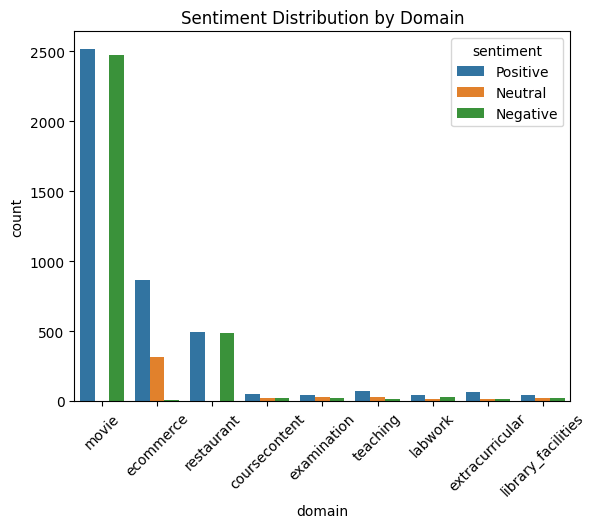

In [31]:
sns.countplot(
    x="domain",
    hue="sentiment",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Sentiment Distribution by Domain"
)

plt.show()

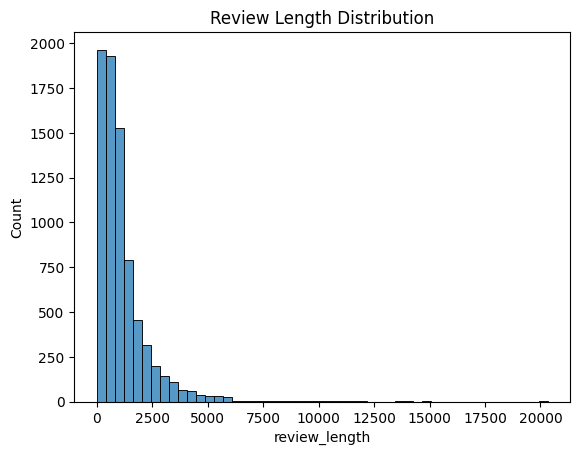

In [32]:
sns.histplot(
    df["review_length"],
    bins=50
)

plt.title(
    "Review Length Distribution"
)

plt.show()

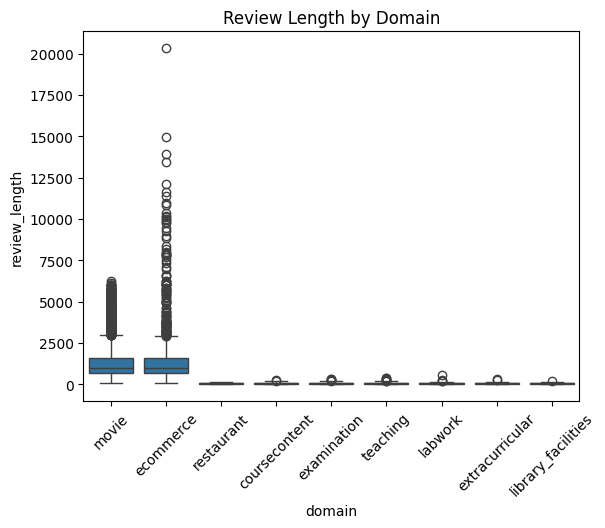

In [33]:
sns.boxplot(
    x="domain",
    y="review_length",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Review Length by Domain"
)

plt.show()

TOP CLEANED WORDS

In [34]:
from collections import Counter

#combined text
all_words = " ".join(
    df["clean_review"]
).split()

In [35]:
common_words = Counter(
    all_words
).most_common(20)

In [36]:
common_df = pd.DataFrame(
    common_words,
    columns=["word", "count"]
)

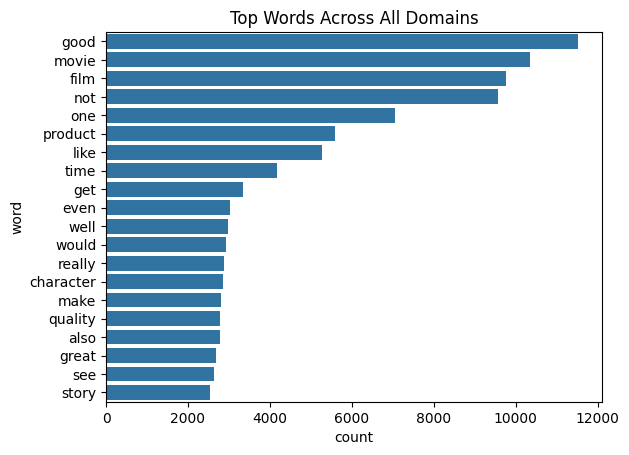

In [37]:
sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title(
    "Top Words Across All Domains"
)

plt.show()

word cloud


In [38]:
from wordcloud import WordCloud

text = " ".join(
    df["clean_review"]
)

In [39]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

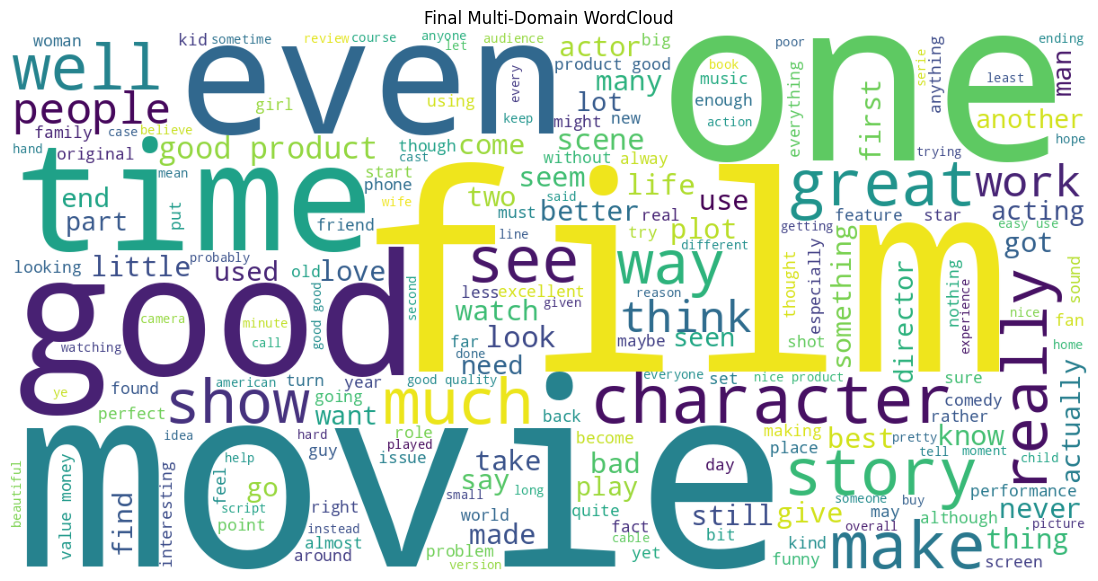

In [40]:
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Final Multi-Domain WordCloud"
)

plt.show()

Heatmap

In [41]:
numeric_df = df.select_dtypes(
    include=np.number
)

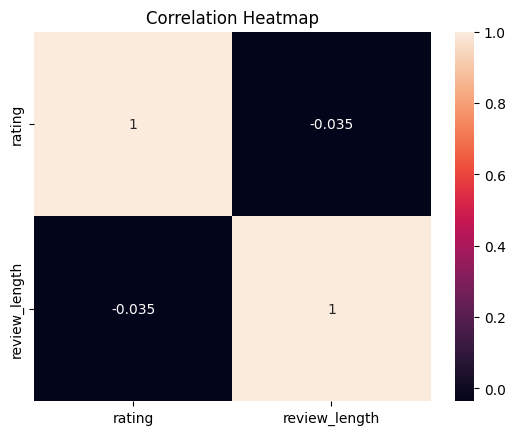

In [42]:
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [43]:
df["sentiment"].value_counts()

sentiment
Positive    4188
Negative    3095
Neutral      439
Name: count, dtype: int64